---
title: Unifying ESG Metrics and Market Performance for Biologic Industries
author: Bryan Armpriest
date: 2025-03-02
categories: [ESG, economics, healthcare, pharmaceuticals]
image: "project.png"
toc: true
---

# Introduction and Background

Stock market data can be a critical indicator for how people feel about the company's growth and future. How much a stock changes from year to year-- regardless of day-to-day ups and downs--can be indicative of their current success or future promise.

Like most companies, those involving biological materials, pharmaceutical preparations, and In Vitro and In Vivo testing can be influenced by the risks that they are exposed to. In particular, risks  However, these industries are likely separated for good reason, and will likely have different risk trends that impact how they do business. I want to expose these trends, and see if they play an impact on their annual market data. Combining market data and ESG ratings to see if there are general trends in industries can be a powerful tool to measure the impact of external aspects, and if the ESG risk score really matters when considering investments.

Research Question: Are annual stock prices of biology-related companies associated with their exposure to long-term risks from social, environmental, and governance sources? Particularly, do in-vitro/in-vivo diagnostic-producing companies have higher risk scores and therefore lower stock prices? I also want to take a look at controversy scores for each of these companies.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Data Collection

Initially, I was provided with esg_proj_2024_data, and esg_proj_2025.

Using selenium in the Spyder IDE, I was able to obtain and clean two DataFrames from Yahoo! Finance. The first, was a DataFrame involving stocks, their prices, and volatility. This data was collected using a table-scraping method on Yahoo! Finance's website and stored a DataFrame: market_df.

The second DataFrame was also from Yahoo! Finance, and included ESG Risk Ratings for each company in the esg_proj_2024 dataframe.

To begin, I need to merge some of the dataframes together, and clean a bit more to make the data workable. For this project, I will be honing in on 2025 market data, and the most recent ESG Risk data.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
url_2025 = "https://bcdanl.github.io/data/esg_proj_2025.csv"
esg_proj_2025 = pd.read_csv(url_2025)
esg_proj_2025.head()

,Year,Symbol,Name,Sector,Industry,Country,Market_Cap,IPO_Year
0,2025,A,Agilent Technologies Inc. Common Stock,Industrials,Biotechnology: Laboratory Analytical Instruments,United States,3.391867e+10,1999.0
1,2025,A,Agilent Technologies Inc. Common Stock,Industrials,Biotechnology: Laboratory Analytical Instruments,United States,3.391867e+10,1999.0
2,2025,AA,Alcoa Corporation Common Stock,Industrials,Aluminum,United States,8.279121e+09,2016.0
3,2025,AA,Alcoa Corporation Common Stock,Industrials,Aluminum,United States,8.279121e+09,2016.0
4,2025,AAL,American Airlines Group Inc. Common Stock,Consumer Discretionary,Air Freight/Delivery Services,United States,7.325392e+09,NaN


In [ ]:
url_2024 = "https://bcdanl.github.io/data/esg_proj_2024_data.csv"
esg_proj_2024_data = pd.read_csv(url_2024)

esg_proj_2024_data['Year'] = 2024
esg_proj_2024_data.head()

,Year,Symbol,Name,Sector,Industry,Country,Market_Cap,IPO_Year,Total_ESG,Environmental,Social,Governance,Controversy
0,2024,A,Agilent Technologies Inc. Common Stock,Industrials,Biotechnology: Laboratory Analytical Instruments,United States,40365434818,1999.0,13.6,1.1,6.4,6.1,2.0
1,2024,AA,Alcoa Corporation Common Stock,Industrials,Aluminum,United States,6622135551,2016.0,24.0,13.8,5.9,4.3,3.0
2,2024,AAL,American Airlines Group Inc. Common Stock,Consumer Discretionary,Air Freight/Delivery Services,United States,9088024606,NaN,26.4,9.9,11.6,4.8,2.0
3,2024,AAP,Advance Auto Parts Inc.,Consumer Discretionary,Auto & Home Supply Stores,United States,4474665296,NaN,11.5,0.1,8.3,3.1,2.0
4,2024,AAPL,Apple Inc. Common Stock,Technology,Computer Manufacturing,United States,2614310000000,1980.0,17.2,0.5,7.4,9.4,3.0


Loading the dataframes that I've collected using selenium from Yahoo! Finance

In [ ]:
market_df = pd.read_csv('/content/drive/My Drive/market_clean.csv')
market_df.head()

<ipython-input-87-7d7518a2a53f>:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  market_df = pd.read_csv('/content/drive/My Drive/market_clean.csv')


,Unnamed: 0,Date,Open,High,Low,Close,Adj Close,Volume,Symbol,Year
0,0,2025-03-28,119.21,119.66,116.36,116.69,116.44,1772900,A,2025
1,1,2025-03-27,120.00,120.33,118.73,118.97,118.72,2075700,A,2025
2,2,2025-03-26,120.72,121.14,119.05,119.90,119.65,2652900,A,2025
3,3,2025-03-25,122.60,123.04,119.76,120.51,120.25,1605900,A,2025
4,4,2025-03-24,121.88,124.43,120.89,121.97,121.71,1557400,A,2025


In [ ]:
market_df_2025 = market_df.query("Year == 2025")
market_df_2025

,Unnamed: 0,Date,Open,High,Low,Close,Adj Close,Volume,Symbol,Year
0,0,2025-03-28,119.21,119.66,116.36,116.69,116.44,1772900,A,2025
1,1,2025-03-27,120.00,120.33,118.73,118.97,118.72,2075700,A,2025
2,2,2025-03-26,120.72,121.14,119.05,119.90,119.65,2652900,A,2025
3,3,2025-03-25,122.60,123.04,119.76,120.51,120.25,1605900,A,2025
4,4,2025-03-24,121.88,124.43,120.89,121.97,121.71,1557400,A,2025
...,...,...,...,...,...,...,...,...,...,...
206502,209101,2025-01-08,30.51,30.70,30.21,30.68,30.68,1048000,MFC,2025
206503,209102,2025-01-07,30.90,31.03,30.47,30.66,30.66,971900,MFC,2025
206504,209103,2025-01-06,31.09,31.25,30.76,30.81,30.81,999300,MFC,2025
206505,209104,2025-01-03,30.74,30.82,30.53,30.67,30.67,824500,MFC,2025


In [ ]:
annual_summary_2025 = market_df_2025.groupby(['Symbol']).agg(
    first_close = ('Close', 'first'),
    last_close = ('Close', 'last')
).reset_index()

annual_summary_2025[['first_close', 'last_close']] = annual_summary_2025[['first_close', 'last_close']].astype('float')

annual_summary_2025['Annual Total Return'] = annual_summary_2025['last_close']/(annual_summary_2025['first_close'] - 1)
annual_summary_2025.head() #This is going to be a very nice, clean DataFrame to work with

,Symbol,first_close,last_close,Annual Total Return
0,A,116.69,133.43,1.153341
1,AA,30.66,37.99,1.280850
2,AAL,10.70,17.00,1.752577
3,AAP,38.95,48.14,1.268511
4,AAPL,217.90,243.85,1.124251


In [ ]:
esg_df = pd.read_csv('/content/drive/My Drive/project_data_2.csv')
esg_df.head()

,Total_ESG,Environmental,Social,Governance,Controversy,Symbol
0,10.1,1.1,5.0,3.9,1.0,A
1,25.1,14.7,8.0,2.4,3.0,AA
2,23.8,9.6,11.3,2.9,2.0,AAL
3,10.7,0.2,8.2,2.3,2.0,AAP
4,18.8,2.0,8.4,8.4,3.0,AAPL


In [ ]:
# Allow me to combine the ESG DataFrame with the esg_proj_2025 DataFrame
esg_merged = pd.merge(esg_df, annual_summary_2025, on = 'Symbol', how = 'inner')
esg_merged #I'm unsure where all of the NaN values are coming from here.

,Total_ESG,Environmental,Social,Governance,Controversy,Symbol,first_close,last_close,Annual Total Return
0,10.1,1.1,5.0,3.9,1.0,A,116.69,133.43,1.153341
1,25.1,14.7,8.0,2.4,3.0,AA,30.66,37.99,1.280850
2,23.8,9.6,11.3,2.9,2.0,AAL,10.70,17.00,1.752577
3,10.7,0.2,8.2,2.3,2.0,AAP,38.95,48.14,1.268511
4,18.8,2.0,8.4,8.4,3.0,AAPL,217.90,243.85,1.124251
...,...,...,...,...,...,...,...,...,...
344,22.0,9.3,9.0,3.7,3.0,MDLZ,67.72,59.50,0.891787
345,18.7,2.0,10.3,6.4,2.0,MDT,87.63,80.22,0.926007
346,15.1,0.5,7.2,7.4,2.0,MET,79.23,81.78,1.045379
347,32.7,2.4,21.6,8.7,4.0,META,576.74,599.24,1.040817


In [ ]:
esg_proj_2025['Industry'].unique() #I am going to use this line to get a feel for what industries to hone in on.
esg_proj_2025_filtered = esg_proj_2025[['Symbol', 'Industry']].query(
    "Industry == 'Biotechnology: Biological Products (No Diagnostic Substances)' | Industry == 'Biotechnology: In Vitro & In Vivo Diagnostic Substances' | Industry == 'Biotechnology: Pharmaceutical Preparations'")

esg_proj_2025_filtered.head()

esg_proj_2025_filtered['Industry'].value_counts()

## There was an oddly low number of companies under some of the industries of interest.
# There are only 7 companies listed that are involved in diagnostic substances, but there is an abundance of pharmaceutical companies.

,count
Industry,
Biotechnology: Pharmaceutical Preparations,215
Biotechnology: Biological Products (No Diagnostic Substances),77
Biotechnology: In Vitro & In Vivo Diagnostic Substances,7


In [ ]:
#Finally, I want to merge the DataFrame that I just created to the previously merged DataFrame so filter out the industries that we want.
df_all = pd.merge(esg_proj_2025_filtered, esg_merged, on = 'Symbol', how = 'inner')
df_all.head() #Looks good!
df_all['Industry'].value_counts() #We are now down to 16, 4, and 1 companies for the

,count
Industry,
Biotechnology: Pharmaceutical Preparations,9
Biotechnology: Biological Products (No Diagnostic Substances),3
Biotechnology: In Vitro & In Vivo Diagnostic Substances,1


# Descriptive Statistics

In [ ]:
esg_merged[['Total_ESG', 'Environmental', 'Social', 'Governance', 'Controversy', 'Annual Total Return']].describe()
#Important metrics can be gathered from the more general statistics.
#The average ESG average score is about 20.8, the average controversy score is 1.89, and the average annual total return is about 1.05 (slightly positive)

,Total_ESG,Environmental,Social,Governance,Controversy,Annual Total Return
count,349.000000,349.000000,349.000000,349.000000,324.000000,349.000000
mean,20.603152,6.021777,9.020344,5.559885,1.904321,1.053716
std,6.894848,5.503169,3.518639,2.511559,0.734033,0.150385
min,5.700000,0.000000,0.900000,1.400000,1.000000,0.668582
25%,15.300000,1.800000,6.800000,3.900000,1.000000,0.946971
50%,20.400000,4.000000,9.000000,4.900000,2.000000,1.041594
75%,24.900000,9.400000,11.300000,6.400000,2.000000,1.128365
max,45.200000,31.100000,22.200000,14.600000,4.000000,1.878179


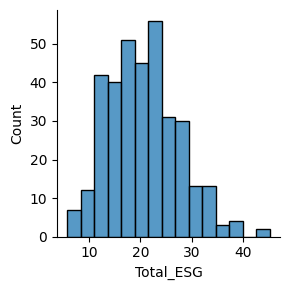

In [ ]:
#Distribution of General ESG Data
(
 sns.FacetGrid(
       data = esg_merged)
 .map(sns.histplot, 'Total_ESG')
 )

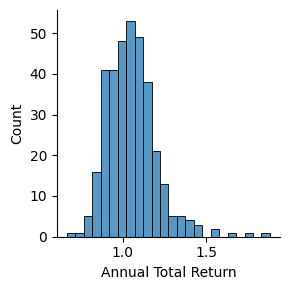

In [ ]:
(
 sns.FacetGrid(
       data = esg_merged)
 .map(sns.histplot, 'Annual Total Return')
 )

In [ ]:
#Next, let's take a look at these three groups in the categories that we wanted to take a look into.
df_all[['Symbol', 'Total_ESG', 'Environmental', 'Social', 'Governance', 'Controversy', 'Annual Total Return']].describe()

,Total_ESG,Environmental,Social,Governance,Controversy,Annual Total Return
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,22.761538,1.884615,14.400000,6.469231,2.230769,0.979758
std,3.860384,1.335319,2.744995,0.945502,1.012739,0.169004
min,16.300000,0.400000,7.700000,5.100000,1.000000,0.829317
25%,20.500000,0.900000,13.000000,6.000000,1.000000,0.878359
50%,22.500000,1.800000,14.600000,6.200000,2.000000,0.943924
75%,23.600000,2.400000,16.000000,7.000000,3.000000,0.985489
max,32.500000,5.500000,18.700000,8.200000,4.000000,1.448905


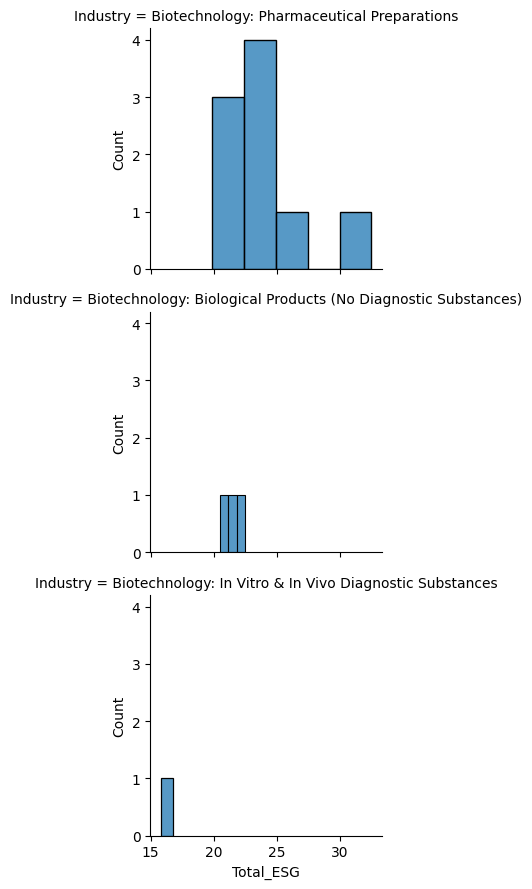

In [ ]:
#Distribution of all three industries in question
(
 sns.FacetGrid(
       data = df_all,
       row='Industry')
 .map(sns.histplot, 'Total_ESG')
 )


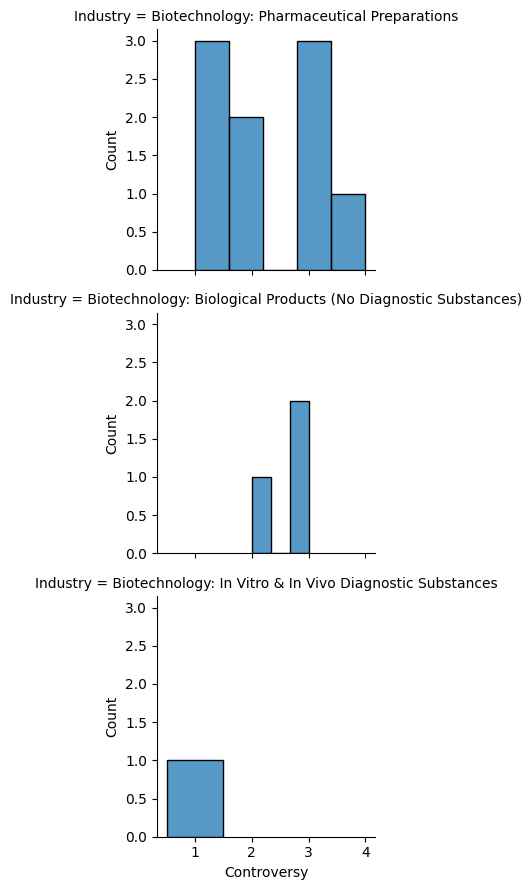

In [ ]:
(
 sns.FacetGrid(
       data = df_all,
       row='Industry')
 .map(sns.histplot, 'Controversy')
 )

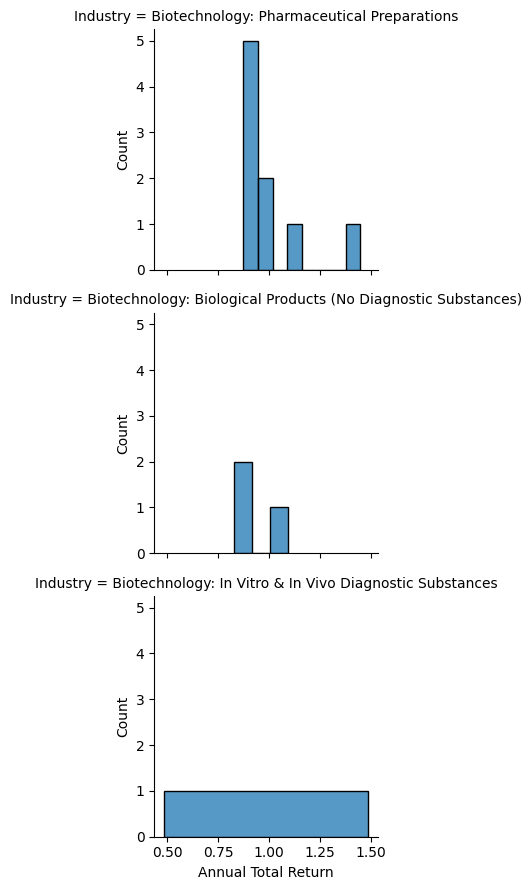

In [ ]:
(
 sns.FacetGrid(
       data = df_all,
       row='Industry')
 .map(sns.histplot, 'Annual Total Return')
 )

# Discussion of Descriptive Statistics of 2025 Bio-Related Companies

Looking at the distributions of ESG values, it looks like there is little variation in the companies dealing with Biological Products and Biotechnology. However, there is incredibly limited data for these two industries. The information that we would get from the correlation of these two would not be informational, so I am going to pivot and focus primarily on Pharmaceutical Preparations.

But there are still things that can be said about the small amount of companies that we have available here in these two groups. For the one value we have for In Vitro and In Vivo Diagnostic substances, it had a minimal controversy score and a relatively low ESG risk index as well.

In [ ]:
#Now, let's take a look at how the ESG values have changed from 2024 to 2025
esg_proj_2024_data
esg_proj_2025

esg_exploration = pd.merge(esg_proj_2024_data, esg_merged, on = 'Symbol', how = 'inner')

In [ ]:
esg_exploration

,Year,Symbol,Name,Sector,Industry,Country,Market_Cap,IPO_Year,Total_ESG_x,Environmental_x,...,Governance_x,Controversy_x,Total_ESG_y,Environmental_y,Social_y,Governance_y,Controversy_y,first_close,last_close,Annual Total Return
0,2024,A,Agilent Technologies Inc. Common Stock,Industrials,Biotechnology: Laboratory Analytical Instruments,United States,40365434818,1999.0,13.6,1.1,...,6.1,2.0,10.1,1.1,5.0,3.9,1.0,116.69,133.43,1.153341
1,2024,AA,Alcoa Corporation Common Stock,Industrials,Aluminum,United States,6622135551,2016.0,24.0,13.8,...,4.3,3.0,25.1,14.7,8.0,2.4,3.0,30.66,37.99,1.280850
2,2024,AAL,American Airlines Group Inc. Common Stock,Consumer Discretionary,Air Freight/Delivery Services,United States,9088024606,NaN,26.4,9.9,...,4.8,2.0,23.8,9.6,11.3,2.9,2.0,10.70,17.00,1.752577
3,2024,AAP,Advance Auto Parts Inc.,Consumer Discretionary,Auto & Home Supply Stores,United States,4474665296,NaN,11.5,0.1,...,3.1,2.0,10.7,0.2,8.2,2.3,2.0,38.95,48.14,1.268511
4,2024,AAPL,Apple Inc. Common Stock,Technology,Computer Manufacturing,United States,2614310000000,1980.0,17.2,0.5,...,9.4,3.0,18.8,2.0,8.4,8.4,3.0,217.90,243.85,1.124251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,2024,MDLZ,Mondelez International Inc. Class A Common Stock,Consumer Staples,Packaged Foods,United States,95074769991,NaN,22.0,7.2,...,5.4,3.0,22.0,9.3,9.0,3.7,3.0,67.72,59.50,0.891787
345,2024,MDT,Medtronic plc. Ordinary Shares,Health Care,Biotechnology: Electromedical & Electrotherape...,United States,105881000000,NaN,22.8,1.8,...,7.6,3.0,18.7,2.0,10.3,6.4,2.0,87.63,80.22,0.926007
346,2024,MET,MetLife Inc. Common Stock,Finance,Life Insurance,United States,50915090441,2000.0,16.0,0.7,...,8.8,2.0,15.1,0.5,7.2,7.4,2.0,79.23,81.78,1.045379
347,2024,META,Meta Platforms Inc. Class A Common Stock,Technology,Computer Software: Programming Data Processing,United States,1130130000000,2012.0,34.0,2.7,...,10.3,4.0,32.7,2.4,21.6,8.7,4.0,576.74,599.24,1.040817


In [ ]:
esg_exploration['ESG_diff_pct'] = 100 * (esg_exploration['Total_ESG_y']-esg_exploration['Total_ESG_x'])/esg_exploration['Total_ESG_x']
esg_exploration

,Year,Symbol,Name,Sector,Industry,Country,Market_Cap,IPO_Year,Total_ESG_x,Environmental_x,...,Total_ESG_y,Environmental_y,Social_y,Governance_y,Controversy_y,first_close,last_close,Annual Total Return,ESG_diff,ESG_diff_pct
0,2024,A,Agilent Technologies Inc. Common Stock,Industrials,Biotechnology: Laboratory Analytical Instruments,United States,40365434818,1999.0,13.6,1.1,...,10.1,1.1,5.0,3.9,1.0,116.69,133.43,1.153341,-25.735294,-25.735294
1,2024,AA,Alcoa Corporation Common Stock,Industrials,Aluminum,United States,6622135551,2016.0,24.0,13.8,...,25.1,14.7,8.0,2.4,3.0,30.66,37.99,1.280850,4.583333,4.583333
2,2024,AAL,American Airlines Group Inc. Common Stock,Consumer Discretionary,Air Freight/Delivery Services,United States,9088024606,NaN,26.4,9.9,...,23.8,9.6,11.3,2.9,2.0,10.70,17.00,1.752577,-9.848485,-9.848485
3,2024,AAP,Advance Auto Parts Inc.,Consumer Discretionary,Auto & Home Supply Stores,United States,4474665296,NaN,11.5,0.1,...,10.7,0.2,8.2,2.3,2.0,38.95,48.14,1.268511,-6.956522,-6.956522
4,2024,AAPL,Apple Inc. Common Stock,Technology,Computer Manufacturing,United States,2614310000000,1980.0,17.2,0.5,...,18.8,2.0,8.4,8.4,3.0,217.90,243.85,1.124251,9.302326,9.302326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,2024,MDLZ,Mondelez International Inc. Class A Common Stock,Consumer Staples,Packaged Foods,United States,95074769991,NaN,22.0,7.2,...,22.0,9.3,9.0,3.7,3.0,67.72,59.50,0.891787,0.000000,0.000000
345,2024,MDT,Medtronic plc. Ordinary Shares,Health Care,Biotechnology: Electromedical & Electrotherape...,United States,105881000000,NaN,22.8,1.8,...,18.7,2.0,10.3,6.4,2.0,87.63,80.22,0.926007,-17.982456,-17.982456
346,2024,MET,MetLife Inc. Common Stock,Finance,Life Insurance,United States,50915090441,2000.0,16.0,0.7,...,15.1,0.5,7.2,7.4,2.0,79.23,81.78,1.045379,-5.625000,-5.625000
347,2024,META,Meta Platforms Inc. Class A Common Stock,Technology,Computer Software: Programming Data Processing,United States,1130130000000,2012.0,34.0,2.7,...,32.7,2.4,21.6,8.7,4.0,576.74,599.24,1.040817,-3.823529,-3.823529


<Axes: xlabel='ESG_diff_pct', ylabel='Count'>

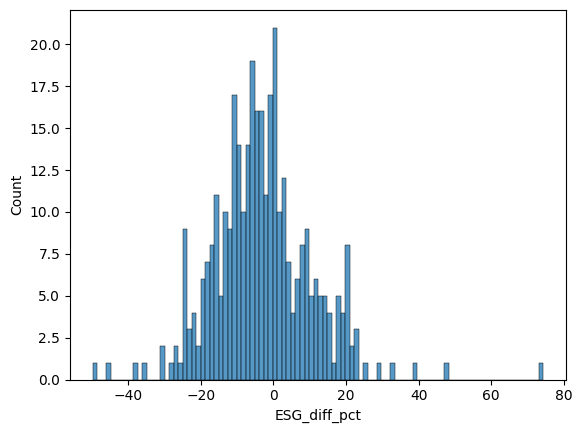

In [ ]:
sns.histplot(data = esg_exploration,
             x =  'ESG_diff_pct',
             bins = 100)

In [ ]:
esg_exploration['ESG_diff_pct'].mean() #The mean difference in the ESG value from each company is about -3.04, meaning that the average movement for the ESG score is in the direction of decreasing

np.float64(-3.035678329026372)

From the above graph, it seems to be quite normally distributed around 0 percent. However, there looks to be more companies with decreasing ESG values, which means that they are moving towards less risk from ESG sources. With this being said, there seems to be a general decrease in the general ESG index value, which points to a decrease in overall risk.

# Questions to Answer (post-EDA)

From above, I have copied the three questions that I had wanted to explore. However, I don't believe that I will be able to produce meaningful results for the second question, since the sample size is miniscule.

1. Are annual stock prices of biology-related companies associated with their exposure to long-term risks from social, environmental, and governance sources?

2. Particularly, do in-vitro/in-vivo diagnostic-producing companies have higher risk scores and therefore lower stock prices?

3. I also want to take a look at controversy scores for each of these companies, and relate it to their annual return.

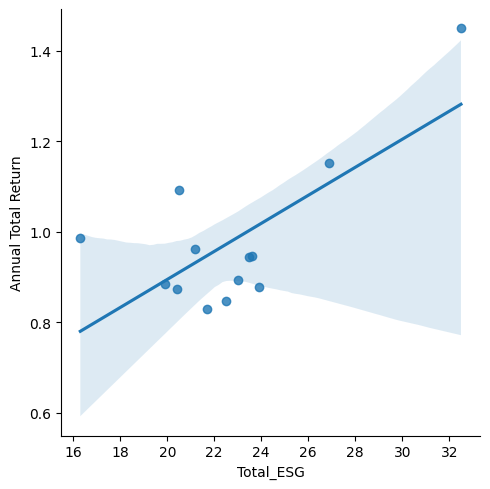

In [ ]:
#1. Is the annual stock return of biology-related companies associated with their exposure to long-term risks from social, environmental, and governance sources?
#df_all.columns
#There were incredibly limited numbers for the companies highlighted in the ESG 2024 data.
sns.lmplot(data = df_all,
           x = 'Total_ESG',
           y = 'Annual Total Return')

There seems to be a generally positive relationship between the ESG Risk indicator and the Annual Total Return of bio-related industries. However, it doesn't seem like it's a very clear relationship, and there is limitation in the data size. Based on the total return, it seems like there is a decrease in the return of many of these companies. Based on the consensus of shareholders, it seems like there is going to be a decline in other metrics, such as profitablity of these companies. In comparison to the average ESG value (about 20), most companies are above that threshold, with one particular company that could be skewing the results of the correlation.

Answer: ESG Risk Score seems to be positively correlated with bio-industry company annual stock return for 2025. This seems odd, seeing how the risks from different sources could be seen as risky investments. But then again, as many say, without risk, there is no reward.

Next, I want to look at the third question I had, which was relating the controversy scores of each bio-related company to their annual total return.

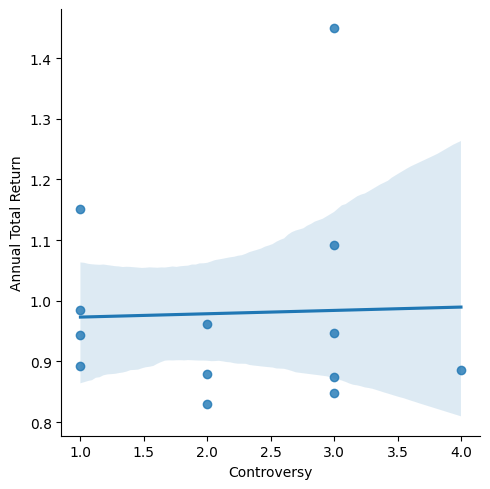

In [ ]:
sns.lmplot(data = df_all,
           x = 'Controversy',
           y = 'Annual Total Return')

In [ ]:
sns.lmplot(data = df_all,
           x = 'Controversy',
           y = 'Annual Total Return')

There are outliers in the DataFrame of controversy levels of bio-industry companies, and there seems to be no relationship between controversy and annual return.

Answer: The relationship between controversy and annual return is ambiguous. There are controversial companies that seem to be successful, whereas there are non-controversial companies that aren't so successful.

# Closing Remarks

Limited by data size, and collection time, I was unable to find conclusive results beside the fact that there was a positive relationship between Annual Total Return and ESG risk score in 2025.

This is an important finding, and could be applied to the understanding of certain stocks. In the biological fields and companies that relate to them, there seems to be a reward for those that are most risky. Creating products that are subject to more governmental, social, and environmental risks can either be beneficial for the business, or lead to loss of favor from stockholders.

# Citations

Yahoo Finance. (n.d.). General stock market data. Retrieved May 15, 2025, from https://finance.yahoo.com

Selenium. (n.d.). SeleniumHQ Browser Automation. https://www.selenium.dev

